In [1]:
import os
import pandas as pd
import missingno as ms
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

from sklearn.metrics import mean_squared_error


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization")

In [4]:
from src.features import Calculations
from src.models import lstm_model
from src.features import Optimization

In [5]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization/data/raw")

In [6]:
portfolio_data = pd.read_csv("Portfolio_data.csv")
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


In [7]:
portfolio_data.size
portfolio_data.shape

(1255, 20)

In [8]:
portfolio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AAPL        1255 non-null   float64
 1   Date_AAPL   1255 non-null   object 
 2   MSFT        1255 non-null   float64
 3   Date_MSFT   1255 non-null   object 
 4   AMZN        1255 non-null   float64
 5   Date_AMZN   1255 non-null   object 
 6   TSLA        1255 non-null   float64
 7   Date_TSLA   1255 non-null   object 
 8   GOOGL       1255 non-null   float64
 9   Date_GOOGL  1255 non-null   object 
 10  META        1255 non-null   float64
 11  Date_META   1255 non-null   object 
 12  NVDA        1255 non-null   float64
 13  Date_NVDA   1255 non-null   object 
 14  JPM         1255 non-null   float64
 15  Date_JPM    1255 non-null   object 
 16  WMT         1255 non-null   float64
 17  Date_WMT    1255 non-null   object 
 18  NFLX        1255 non-null   float64
 19  Date_NFLX   1255 non-null  

In [9]:
portfolio_data[portfolio_data.duplicated()]

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX


In [10]:
date_cols = portfolio_data.select_dtypes(include = "object").columns 
for col in date_cols:
    portfolio_data[col] = pd.to_datetime(portfolio_data[col])

In [11]:
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


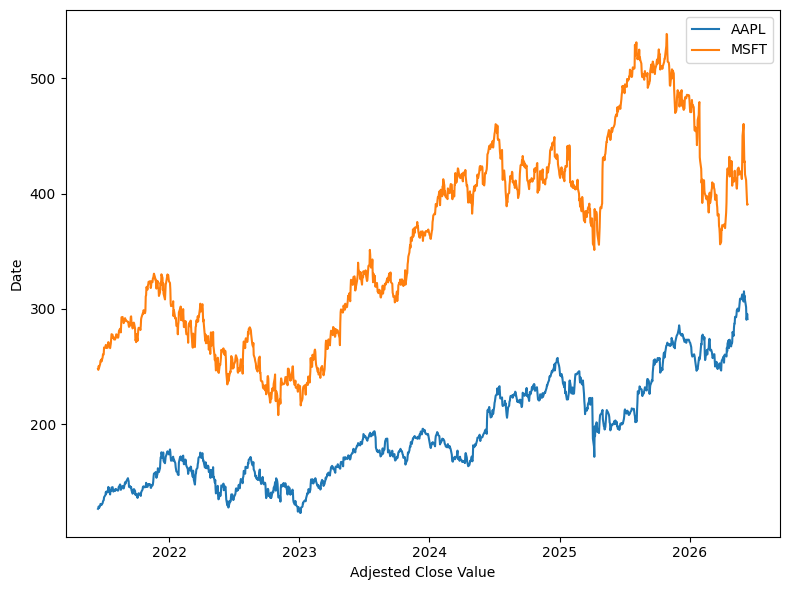

In [12]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[:2]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

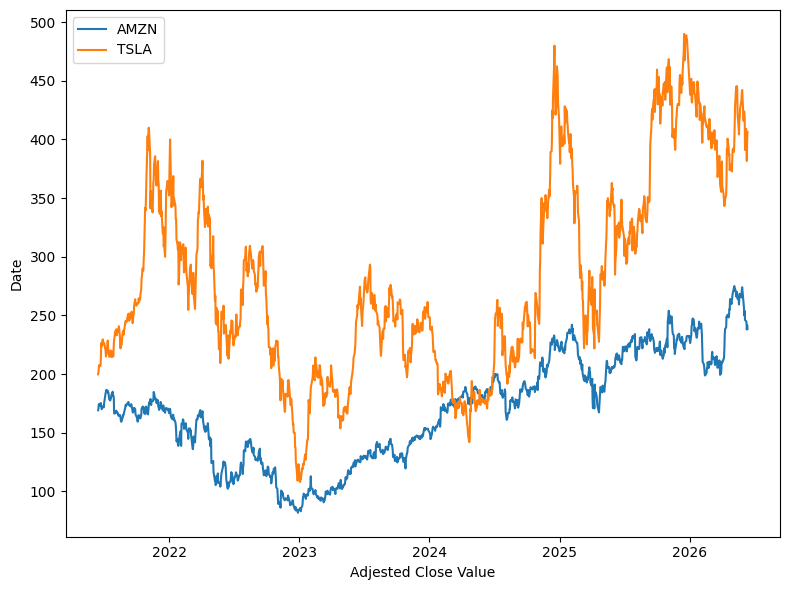

In [13]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[2:4]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

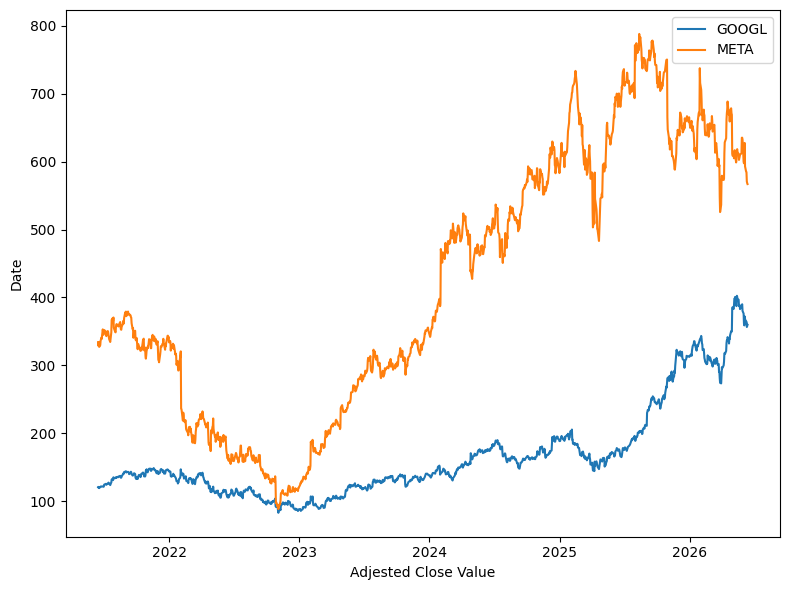

In [14]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[4:6]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

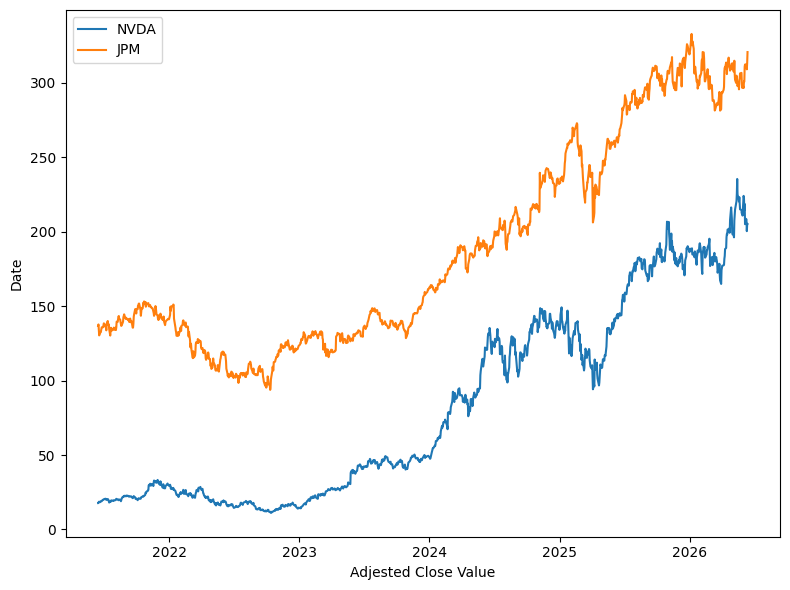

In [15]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[6:8]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

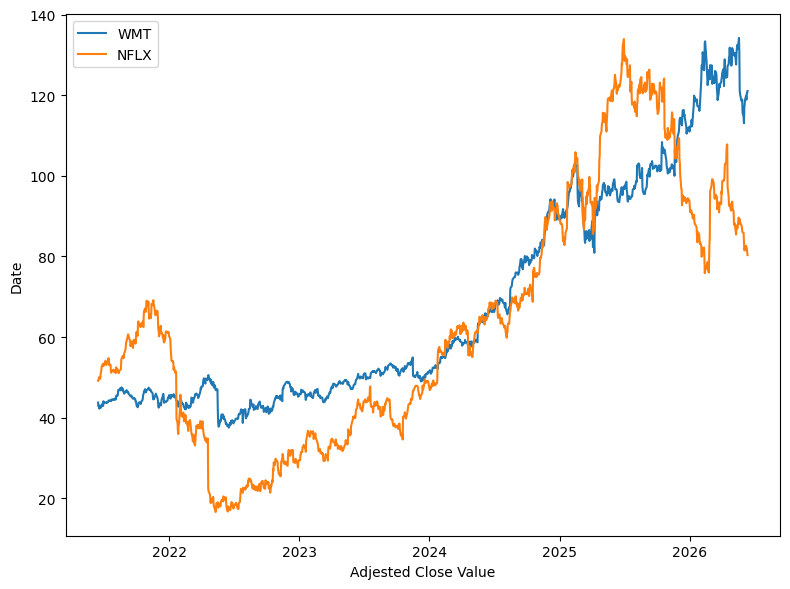

In [16]:
num_cols = portfolio_data.select_dtypes(include = "float64").columns 
plt.figure(figsize = (8, 6))

for col in num_cols[8:]:
    plt.plot(portfolio_data[f"Date_{col}"], portfolio_data[col] , label = col)
plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
portfolio_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,META,Date_META,NVDA,Date_NVDA,JPM,Date_JPM,WMT,Date_WMT,NFLX,Date_NFLX
0,126.366859,2021-06-15,247.947250,2021-06-15,169.156494,2021-06-15,199.786667,2021-06-15,120.352303,2021-06-15,334.127930,2021-06-15,17.727182,2021-06-15,136.760559,2021-06-15,43.781265,2021-06-15,49.189999,2021-06-15
1,126.863953,2021-06-16,247.006790,2021-06-16,170.762497,2021-06-16,201.623337,2021-06-16,119.710999,2021-06-16,328.502014,2021-06-16,17.748856,2021-06-16,137.721207,2021-06-16,42.890003,2021-06-16,49.241001,2021-06-16
2,128.462570,2021-06-17,250.384857,2021-06-17,174.462006,2021-06-17,205.533340,2021-06-17,120.673477,2021-06-17,333.889832,2021-06-17,18.592939,2021-06-17,133.746521,2021-06-17,43.068253,2021-06-17,49.834000,2021-06-17
3,127.166130,2021-06-18,248.974106,2021-06-18,174.345001,2021-06-18,207.770004,2021-06-18,119.055313,2021-06-18,327.093170,2021-06-18,18.574503,2021-06-18,130.362320,2021-06-18,42.270802,2021-06-18,50.077000,2021-06-18
4,128.959671,2021-06-21,252.045166,2021-06-21,172.697998,2021-06-21,206.943329,2021-06-21,120.741852,2021-06-21,329.702637,2021-06-21,18.363735,2021-06-21,132.574417,2021-06-21,42.655457,2021-06-21,49.700001,2021-06-21


In [18]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization/reports")
report = sv.analyze(portfolio_data)
report.show_html("basic_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report basic_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [19]:
apple_data = portfolio_data[["Date_AAPL", "AAPL"]]
apple_data = apple_data.set_index("Date_AAPL")
monthly_data = apple_data.resample("M").sum()

In [20]:
monthly_data.head(6)

,AAPL
Date_AAPL,
2021-06-30,1556.298691
2021-07-31,2970.975693
2021-08-31,3181.507111
2021-09-30,3040.344955
2021-10-31,2984.124847
2021-11-30,3166.071487


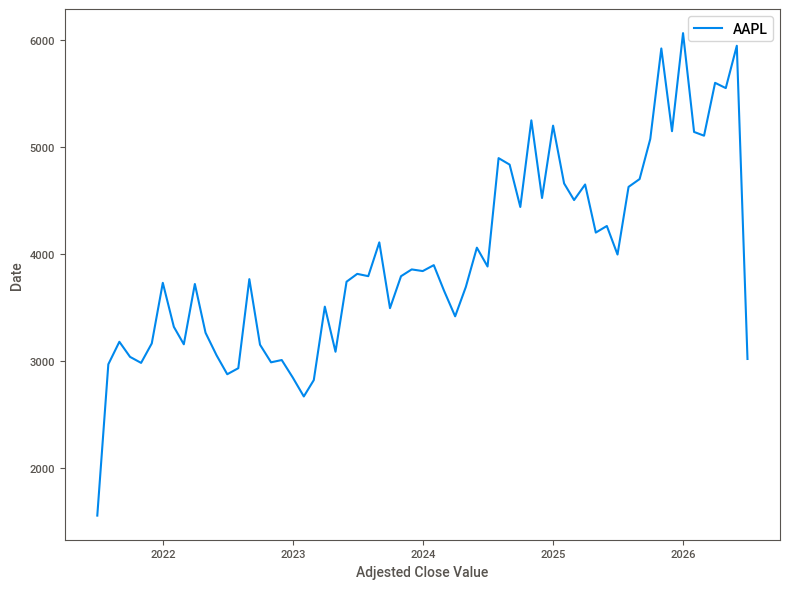

In [21]:
plt.figure(figsize = (8, 6))

plt.plot(monthly_data.index, monthly_data["AAPL"] , label = "AAPL")

plt.xlabel("Adjested Close Value")
plt.ylabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
return_data = Calculations.calculate_returns(portfolio_data)

In [23]:
return_data.tail()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,...,Rolling Std (AAPL),Rolling Std (MSFT),Rolling Std (AMZN),Rolling Std (TSLA),Rolling Std (GOOGL),Rolling Std (META),Rolling Std (NVDA),Rolling Std (JPM),Rolling Std (WMT),Rolling Std (NFLX)
1250,-0.018872,2026-06-08,-0.011832,2026-06-08,-0.003292,2026-06-08,0.045908,2026-06-08,-0.013576,2026-06-08,...,0.012005,0.022879,0.017230,0.030273,0.019276,0.023183,0.029083,0.013960,0.022470,0.014825
1251,-0.036446,2026-06-09,-0.020231,2026-06-09,-0.004200,2026-06-09,-0.030004,2026-06-09,0.002615,2026-06-09,...,0.014705,0.023292,0.017117,0.029296,0.018355,0.022879,0.028669,0.013833,0.022103,0.014321
1252,0.003545,2026-06-10,-0.014997,2026-06-10,-0.025349,2026-06-10,-0.038041,2026-06-10,-0.021633,2026-06-10,...,0.014628,0.023381,0.017673,0.029863,0.018821,0.023325,0.029636,0.013731,0.021729,0.012930
1253,0.013890,2026-06-11,-0.017667,2026-06-11,0.014748,2026-06-11,0.046018,2026-06-11,0.003900,2026-06-11,...,0.014633,0.023656,0.017582,0.031223,0.015972,0.022567,0.029604,0.013497,0.021552,0.012979
1254,-0.015222,2026-06-12,0.001025,2026-06-12,-0.012256,2026-06-12,0.018239,2026-06-12,0.005339,2026-06-12,...,0.015000,0.023499,0.017609,0.031653,0.016160,0.022514,0.027403,0.014242,0.021476,0.013077


In [24]:
return_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   AAPL                  1254 non-null   float64       
 1   Date_AAPL             1255 non-null   datetime64[ns]
 2   MSFT                  1254 non-null   float64       
 3   Date_MSFT             1255 non-null   datetime64[ns]
 4   AMZN                  1254 non-null   float64       
 5   Date_AMZN             1255 non-null   datetime64[ns]
 6   TSLA                  1254 non-null   float64       
 7   Date_TSLA             1255 non-null   datetime64[ns]
 8   GOOGL                 1254 non-null   float64       
 9   Date_GOOGL            1255 non-null   datetime64[ns]
 10  META                  1254 non-null   float64       
 11  Date_META             1255 non-null   datetime64[ns]
 12  NVDA                  1254 non-null   float64       
 13  Date_NVDA         

In [25]:
return_data.dropna(inplace = True)

In [26]:
return_data.head()

,AAPL,Date_AAPL,MSFT,Date_MSFT,AMZN,Date_AMZN,TSLA,Date_TSLA,GOOGL,Date_GOOGL,...,Rolling Std (AAPL),Rolling Std (MSFT),Rolling Std (AMZN),Rolling Std (TSLA),Rolling Std (GOOGL),Rolling Std (META),Rolling Std (NVDA),Rolling Std (JPM),Rolling Std (WMT),Rolling Std (NFLX)
20,0.024101,2021-07-14,0.005445,2021-07-14,0.001175,2021-07-14,-0.022676,2021-07-14,0.007032,2021-07-14,...,0.009742,0.008359,0.014637,0.022616,0.008236,0.015464,0.019808,0.014977,0.010691,0.009540
21,-0.004492,2021-07-15,-0.005239,2021-07-15,-0.013711,2021-07-15,-0.004255,2021-07-15,-0.009607,2021-07-15,...,0.010062,0.008440,0.015119,0.022671,0.008509,0.015068,0.022722,0.014903,0.009487,0.010045
22,-0.014076,2021-07-16,-0.000996,2021-07-16,-0.015854,2021-07-16,-0.009806,2021-07-16,-0.000275,2021-07-16,...,0.010961,0.008230,0.015032,0.022560,0.008429,0.014888,0.022427,0.014336,0.009482,0.011700
23,-0.026915,2021-07-19,-0.013321,2021-07-19,-0.006727,2021-07-19,0.003104,2021-07-19,-0.018839,2021-07-19,...,0.012712,0.008846,0.015134,0.022474,0.009023,0.014389,0.023767,0.015089,0.008309,0.011694
24,0.025974,2021-07-20,0.008339,2021-07-20,0.006649,2021-07-20,0.022098,2021-07-20,0.013096,2021-07-20,...,0.013441,0.008675,0.014977,0.022859,0.008949,0.014599,0.023709,0.015192,0.008172,0.011501


In [27]:
def train_model(ticker, predicted_ext_returns):
    
    return_data[f"exspected_return ({ticker})"] = return_data[f"Log Returns ({ticker})"].shift(-1)
    return_data.dropna(inplace = True)
    
    x = return_data[[f"{ticker}", f"Rolling Mean ({ticker})", f"Rolling Std ({ticker})"]]
    y = return_data[f"exspected_return ({ticker})"]

    model, X_seq, y_seq, x_scaled = lstm_model.train_lstm_model(x, y)

    split = int(len(X_seq) * 0.8)
    X_train = X_seq[:split]
    X_test = X_seq[split:]
    y_train = y_seq[:split]
    y_test = y_seq[split:]

    history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
    )

    prediction = model.predict(X_test)

    mse = mean_squared_error(
    y_test,
    prediction
    )

    latest_sequence = x_scaled[-90:]

    latest_sequence = latest_sequence.reshape(1,90,3)
    future_return = model.predict(
    latest_sequence
    )
    predicted_return = np.exp(
    future_return
    ) - 1
    
    predicted_ext_returns[f"exp_return ({ticker})"] = predicted_return.item()
    predicted_ext_returns[f"MSE of ({ticker})"] = mse

    return model,predicted_ext_returns

In [28]:
predicted_ext_returns = {}
tickers = ["AAPL", "MSFT", "AMZN", "TSLA", "GOOGL", "META", "NVDA", "JPM", "WMT", "NFLX"]

for ticker in tickers:
    model,predicted_ext_returns = train_model(ticker, predicted_ext_returns)
    report = pd.DataFrame([predicted_ext_returns])
    print(report)

    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization/models")
    model.save(f"{ticker}_lstm_model.keras")

(1144, 90, 3)
(1144,)
Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 3.8791e-04 - val_loss: 8.2177e-04
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 3.1782e-04 - val_loss: 8.4208e-04
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 3.1288e-04 - val_loss: 8.2135e-04
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 3.0712e-04 - val_loss: 8.2538e-04
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 3.0720e-04 - val_loss: 8.2681e-04
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 3.3787e-04 - val_loss: 8.9518e-04
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 3.1087e-04 - val_loss: 8.3426e-04
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3.1524e-04 - val_loss: 8.0272e-04
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.1898e-04 - val_loss: 8.3456e-04
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - l

In [29]:
predicted_ext_returns

{'exp_return (AAPL)': -0.008695006370544434,
 'MSE of (AAPL)': 0.0002751363277541474,
 'exp_return (MSFT)': -0.0008993148803710938,
 'MSE of (MSFT)': 0.0002834868826166176,
 'exp_return (AMZN)': -0.0016228556632995605,
 'MSE of (AMZN)': 0.000384160786427171,
 'exp_return (TSLA)': -0.006844460964202881,
 'MSE of (TSLA)': 0.000784368416551436,
 'exp_return (GOOGL)': 0.006366133689880371,
 'MSE of (GOOGL)': 0.0003529069875112268,
 'exp_return (META)': -0.0021888017654418945,
 'MSE of (META)': 0.0005421363310630871,
 'exp_return (NVDA)': 0.005022287368774414,
 'MSE of (NVDA)': 0.0005303453830785048,
 'exp_return (JPM)': 0.003666400909423828,
 'MSE of (JPM)': 0.00019390494232709505,
 'exp_return (WMT)': 0.001560807228088379,
 'MSE of (WMT)': 0.000234450626345512,
 'exp_return (NFLX)': 0.005336880683898926,
 'MSE of (NFLX)': 0.0005132801771217315}

In [30]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Stock Portfolio Performance Optimization/reports")
report.to_excel("predicted_ext_returns.xlsx", index = False)

In [31]:
report.head()

,exp_return (AAPL),MSE of (AAPL),exp_return (MSFT),MSE of (MSFT),exp_return (AMZN),MSE of (AMZN),exp_return (TSLA),MSE of (TSLA),exp_return (GOOGL),MSE of (GOOGL),exp_return (META),MSE of (META),exp_return (NVDA),MSE of (NVDA),exp_return (JPM),MSE of (JPM),exp_return (WMT),MSE of (WMT),exp_return (NFLX),MSE of (NFLX)
0,-0.008695,0.000275,-0.000899,0.000283,-0.001623,0.000384,-0.006844,0.000784,0.006366,0.000353,-0.002189,0.000542,0.005022,0.00053,0.003666,0.000194,0.001561,0.000234,0.005337,0.000513


In [32]:
returns_columns = [col for col in return_data.columns if "Log Returns" in col]
expected_returns = [0.008435, 0.000237, -0.004466, 0.004053, -0.002978, -0.000822, 0.006449, 0.002782, 0.002167, 0.002757]
cov_matrix = return_data[returns_columns].cov()

# Define optimization constraints (e.g., minimum/maximum allocation, target return)
constraints = {
    "min_allocation": [0.0] * len(tickers),  # Minimum allocation for each asset
    "max_allocation": [1.0] * len(tickers),  # Maximum allocation for each asset
}

# Define the risk-free rate (adjust as needed)
risk_free_rate = 0.03  # Example risk-free rate

In [33]:
cov_matrix

,Log Returns (AAPL),Log Returns (MSFT),Log Returns (AMZN),Log Returns (TSLA),Log Returns (GOOGL),Log Returns (META),Log Returns (NVDA),Log Returns (JPM),Log Returns (WMT),Log Returns (NFLX)
Log Returns (AAPL),0.000301,0.000168,0.000211,0.000313,0.000192,0.000226,0.000281,0.000101,0.000062,0.000179
Log Returns (MSFT),0.000168,0.000283,0.000235,0.000253,0.000193,0.000260,0.000328,0.000083,0.000043,0.000191
Log Returns (AMZN),0.000211,0.000235,0.000506,0.000370,0.000274,0.000375,0.000399,0.000128,0.000068,0.000286
Log Returns (TSLA),0.000313,0.000253,0.000370,0.001386,0.000306,0.000356,0.000568,0.000185,0.000080,0.000339
Log Returns (GOOGL),0.000192,0.000193,0.000274,0.000306,0.000393,0.000298,0.000331,0.000100,0.000050,0.000196
Log Returns (META),0.000226,0.000260,0.000375,0.000356,0.000298,0.000794,0.000449,0.000132,0.000061,0.000339
Log Returns (NVDA),0.000281,0.000328,0.000399,0.000568,0.000331,0.000449,0.001057,0.000167,0.000047,0.000373
Log Returns (JPM),0.000101,0.000083,0.000128,0.000185,0.000100,0.000132,0.000167,0.000237,0.000044,0.000107
Log Returns (WMT),0.000062,0.000043,0.000068,0.000080,0.000050,0.000061,0.000047,0.000044,0.000189,0.000055
Log Returns (NFLX),0.000179,0.000191,0.000286,0.000339,0.000196,0.000339,0.000373,0.000107,0.000055,0.000805


In [34]:
optimization_results = Optimization.optimize_portfolio(expected_returns, cov_matrix, constraints, risk_free_rate)

In [35]:
optimization_results

{'Portfolio Weights': array([1., 1., 0., 1., 0., 0., 1., 1., 1., 1.]),
 'Portfolio Return': np.float64(0.026879999999999994),
 'Portfolio Volatility': np.float64(0.11042380789202895),
 'Sharpe Ratio': np.float64(-0.028254776388898874)}

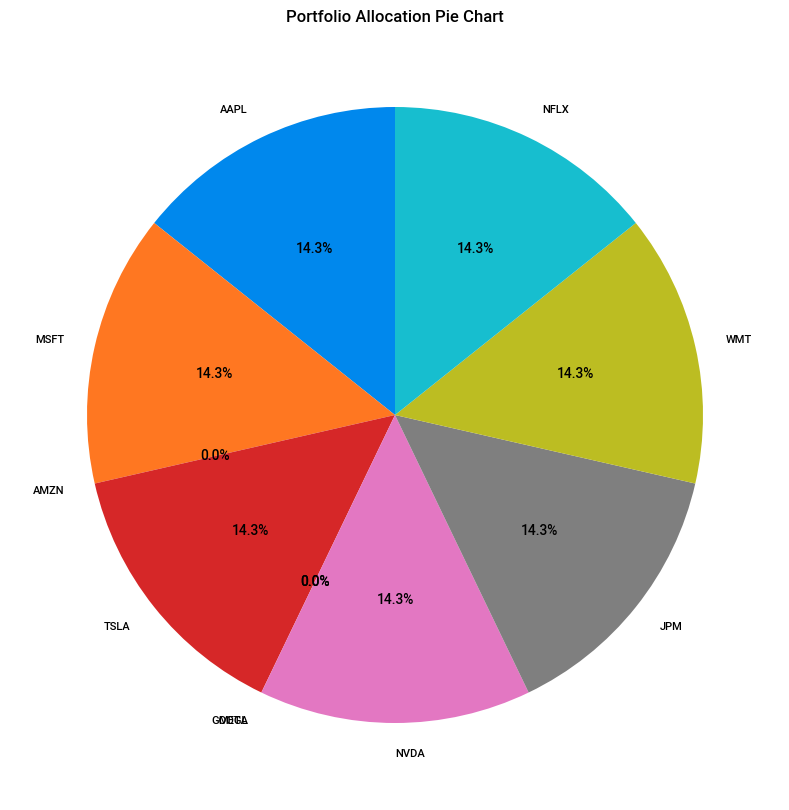

In [36]:
# Create a pie chart to visualize the portfolio allocation
plt.figure(figsize=(15, 10))
plt.pie(optimization_results["Portfolio Weights"], 
        labels=tickers, 
        autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Allocation Pie Chart")
plt.show()